# Geo-FNO Test: Node-Type Model (Asymmetrical Modes/Grid)

Loads the model trained in `geo_FNO_train.ipynb` and visualizes input, ground truth, prediction, and difference for one sample.


Using L_global from sample_000000 : [1.600000023841858, 0.4099999964237213]
sample=sample_000034 | MSE(all velocity components)=1.162540e-03


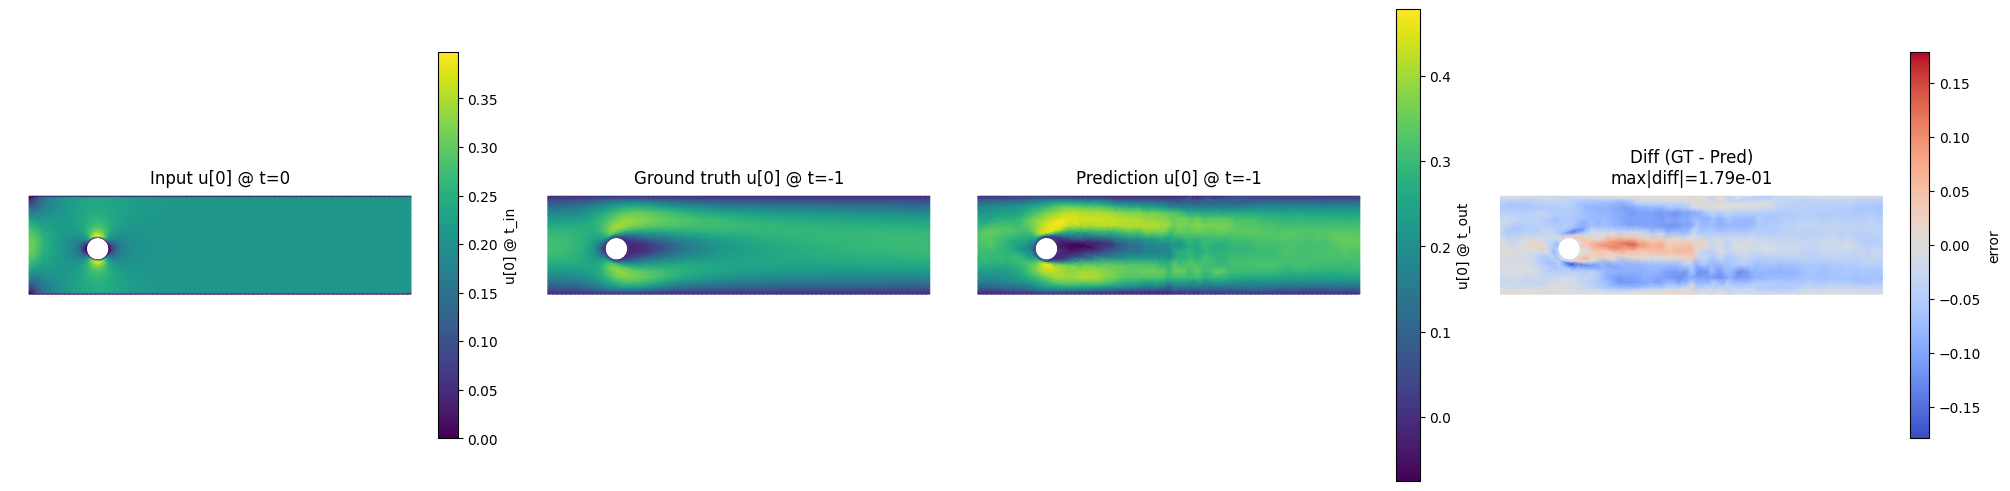

In [1]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as tri

from geo_FNO_def import FNO2d, IPHI, get_global_L_from_h5

# ----------------------------
# Config
# ----------------------------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/test.h5"
sample_id = "sample_000034"
t_in = 0
t_out = -1
component = 0  # 0 -> u_x, 1 -> u_y

# Must match train-time one-hot mapping
NODE_TYPE_VALUES = [0, 4, 5, 6]
NODE_TYPE_TO_IDX = {v: i for i, v in enumerate(NODE_TYPE_VALUES)}

# Must match geo_FNO_train.ipynb run cell
modes1 = 24
modes2 = 12
width = 32
s1 = 100
s2 = 25

# Must match geo_FNO_train.ipynb save cell
FNO_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_asymmetrical_fno.pt"
IPHI_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_with_node_type_asymmetrical_iphi.pt"

boundary_label = 6
band_frac = 0.06

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# ----------------------------
# Geometry utilities
# ----------------------------
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a*a + b_*b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)


def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray,
                                  boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]
    xc, yc, r = fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])
    return xc, yc, r


def build_node_onehot(node_type: np.ndarray):
    feat = np.zeros((node_type.shape[0], len(NODE_TYPE_VALUES)), dtype=np.float32)
    for i, nt in enumerate(node_type.astype(np.int32)):
        feat[i, NODE_TYPE_TO_IDX[int(nt)]] = 1.0
    return feat


# ----------------------------
# Load one sample
# ----------------------------
with h5py.File(H5_PATH, "r") as f:
    g = f[sample_id]
    pos = g["pos"][:]                 # (N,2)
    cells = g["cells"][:]             # (C,3)
    node_type = g["node_type"][:]     # (N,)
    vel = g["vel"][:]                 # (T,N,2)

u_vel_in = vel[t_in].astype(np.float32)               # (N,2)
u_out = vel[t_out].astype(np.float32)                # (N,2)
node_feat = build_node_onehot(node_type)              # (N,K)
u_in = np.concatenate([u_vel_in, node_feat], axis=-1)  # (N,2+K)

xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=boundary_label, band_frac=band_frac)
code42 = np.zeros((42,), dtype=np.float32)
code42[0], code42[1], code42[2] = xc, yc, r


# ----------------------------
# Load model
# ----------------------------
L_global, key_used = get_global_L_from_h5(H5_PATH)
print("Using L_global from", key_used, ":", L_global)

in_channels = 2 + len(NODE_TYPE_VALUES)
model = FNO2d(
    modes1,
    modes2,
    width,
    in_channels=in_channels,
    out_channels=2,
    is_mesh=False,
    s1=s1,
    s2=s2,
    L=L_global,
).to(device)
model_iphi = IPHI(width=32, device=str(device)).to(device)

model.load_state_dict(torch.load(FNO_CKPT, map_location=device), strict=False)
model_iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device), strict=False)
model.eval()
model_iphi.eval()


# ----------------------------
# Predict
# ----------------------------
pos_t = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)
u_in_t = torch.from_numpy(u_in).unsqueeze(0).to(device)
code_t = torch.from_numpy(code42).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(u_in_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=model_iphi)[0].cpu().numpy().astype(np.float32)

mse = float(np.mean((pred - u_out) ** 2))
print(f"sample={sample_id} | MSE(all velocity components)={mse:.6e}")


# ----------------------------
# Plot
# ----------------------------
triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)

inp_field = u_vel_in[:, component]
gt_field = u_out[:, component]
pred_field = pred[:, component]
diff_field = gt_field - pred_field

common_min = float(min(gt_field.min(), pred_field.min()))
common_max = float(max(gt_field.max(), pred_field.max()))
diff_abs = float(np.max(np.abs(diff_field)))

fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)

im0 = axes[0].tripcolor(triang, inp_field, shading="gouraud")
axes[0].set_title(f"Input u[{component}] @ t={t_in}")
axes[0].set_aspect("equal")
axes[0].axis("off")

im1 = axes[1].tripcolor(triang, gt_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[1].set_title(f"Ground truth u[{component}] @ t={t_out}")
axes[1].set_aspect("equal")
axes[1].axis("off")

im2 = axes[2].tripcolor(triang, pred_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[2].set_title(f"Prediction u[{component}] @ t={t_out}")
axes[2].set_aspect("equal")
axes[2].axis("off")

im3 = axes[3].tripcolor(triang, diff_field, shading="gouraud", vmin=-diff_abs, vmax=diff_abs, cmap="coolwarm")
axes[3].set_title(f"Diff (GT - Pred)\nmax|diff|={diff_abs:.2e}")
axes[3].set_aspect("equal")
axes[3].axis("off")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label=f"u[{component}] @ t_in")
fig.colorbar(im1, ax=[axes[1], axes[2]], fraction=0.046, pad=0.02, label=f"u[{component}] @ t_out")
fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.02, label="error")
plt.show()

